In [14]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.linear_model import LinearRegression,Lasso,Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [15]:
df = pd.read_csv('ToyotaCorolla - MLR.csv')
df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [16]:
df.shape

(1436, 11)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


In [18]:
df.drop(columns= ['Fuel_Type'],inplace =True )

In [19]:
### Handling Missing value 

df.isnull().sum()

Price        0
Age_08_04    0
KM           0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64

In [20]:
df.duplicated().sum()

np.int64(1)

In [21]:
df.drop_duplicates(inplace=True)

In [22]:
df.duplicated().sum()

np.int64(0)

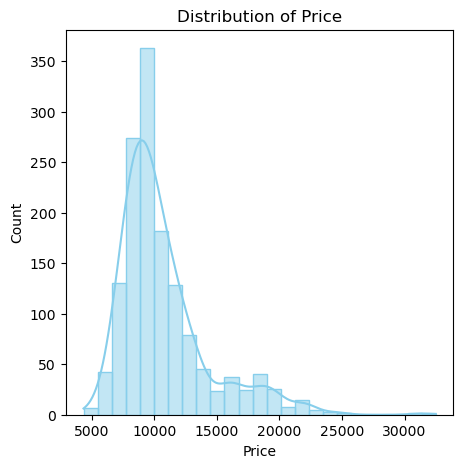

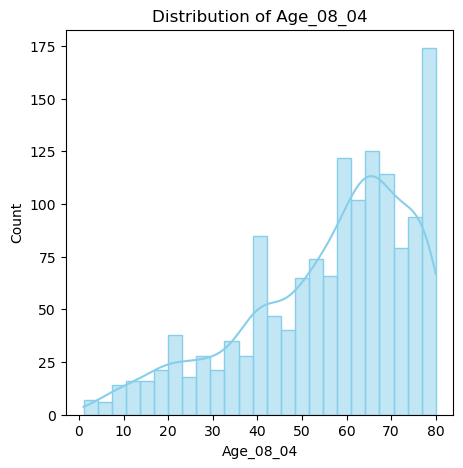

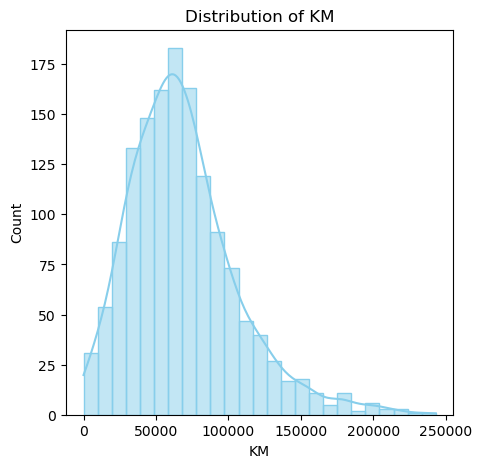

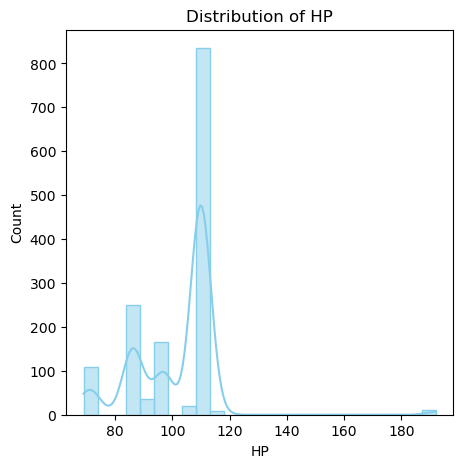

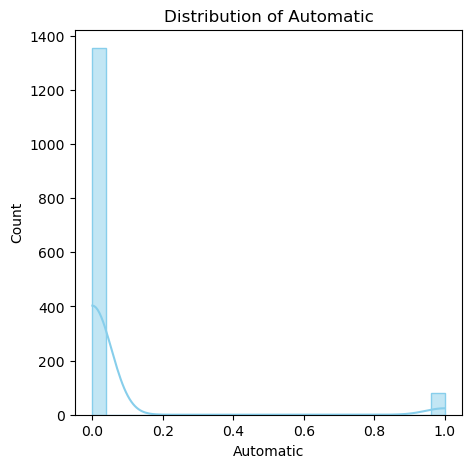

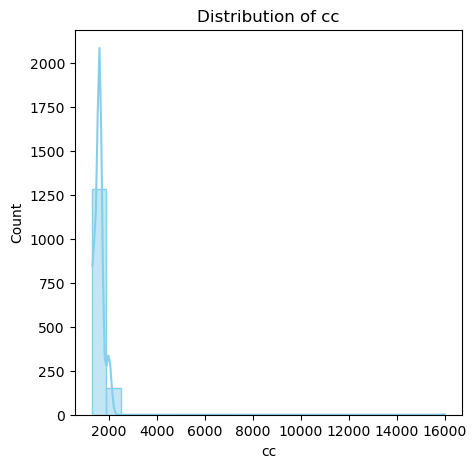

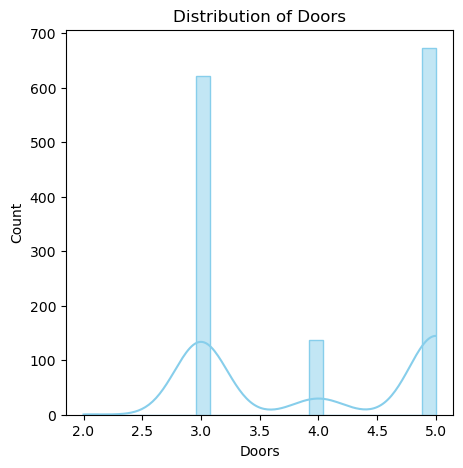

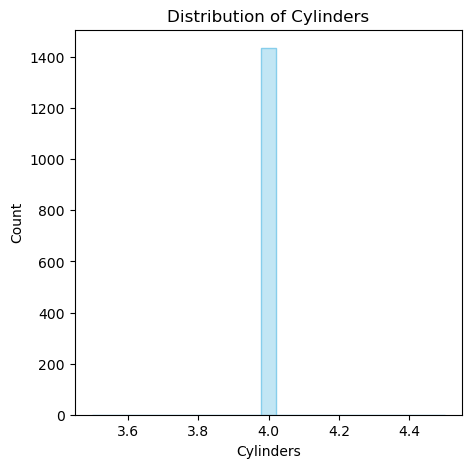

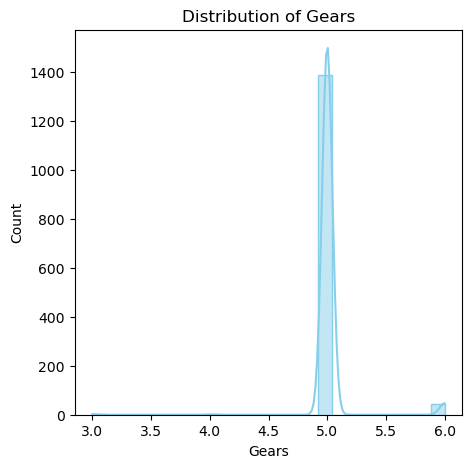

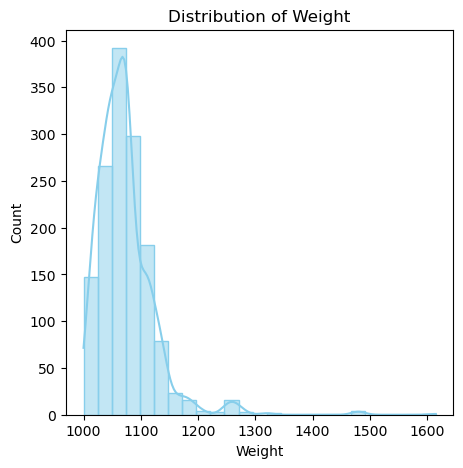

In [23]:
### Data Visualization 

for i in ['Price','Age_08_04','KM','HP','Automatic','cc','Doors','Cylinders','Gears','Weight']:
    plt.figure(figsize = (5,5))
    sns.histplot(x = df[i],bins = 25,color = 'skyblue',edgecolor = 'skyblue',kde = True)
    plt.title(f'Distribution of {i}')

<Axes: >

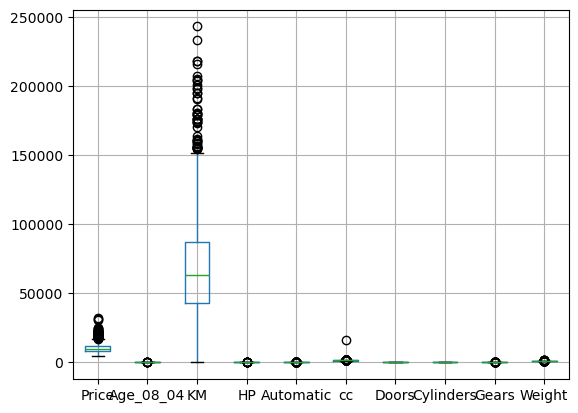

In [24]:
### Box Plot 
df.boxplot()

In [25]:
#### outlier capping
def outiler_capping(df,column):
    Q1= df[column].quantile(0.25)
    Q3= df[column].quantile(0.75)
    IQR=Q3-Q1
    Lower_Extreme= Q1-1.5*IQR
    Upper_Extreme= Q3+1.5*IQR
    df[column]= df[column].apply(lambda x:Lower_Extreme if x<Lower_Extreme else Upper_Extreme if x>Upper_Extreme else x)
for col in df.select_dtypes(['int','float']).columns:
    outiler_capping(df,col)

<Axes: >

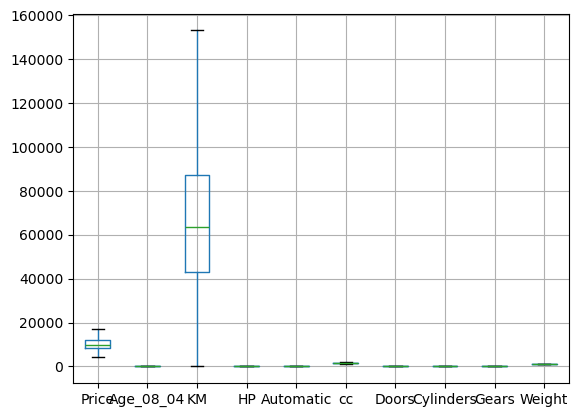

In [27]:
df.boxplot()

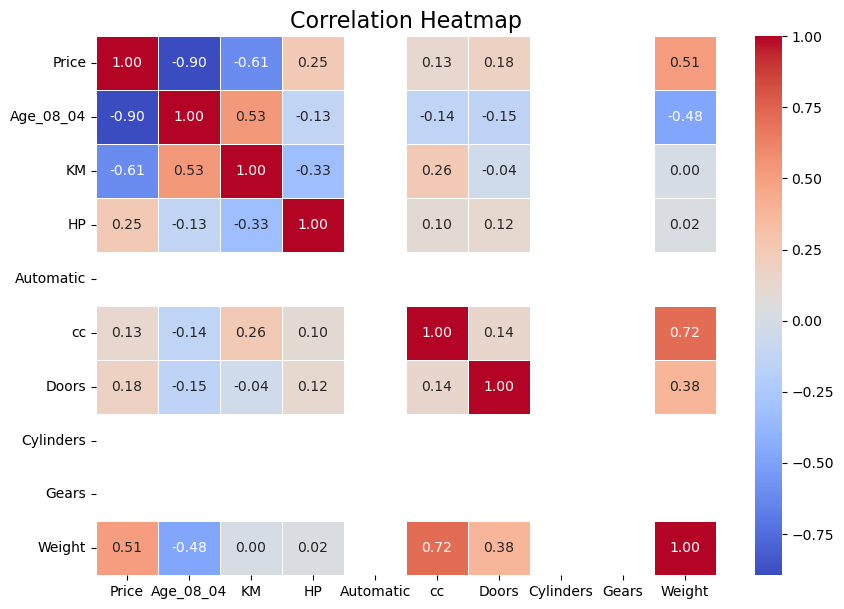

In [28]:
corr = df.corr()

# Plot heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap", fontsize=16)
plt.show()

In [29]:
### x_train and y_train
df.head()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500.0,23.0,46986.0,90.0,0.0,1900.0,3,4,5.0,1152.5
1,13750.0,23.0,72937.0,90.0,0.0,1900.0,3,4,5.0,1152.5
2,13950.0,24.0,41711.0,90.0,0.0,1900.0,3,4,5.0,1152.5
3,14950.0,26.0,48000.0,90.0,0.0,1900.0,3,4,5.0,1152.5
4,13750.0,30.0,38500.0,90.0,0.0,1900.0,3,4,5.0,1152.5


### Simple Linear Regression 

In [30]:
lin_reg=LinearRegression()
lin_reg.fit(df[['KM']],df.Price)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [31]:
lin_reg.predict([[46986]])

C:\Users\saran\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([11572.88865851])

In [32]:
lin_reg.intercept_

np.float64(14022.258674155702)

In [33]:
lin_reg.coef_

array([-0.05212978])

In [34]:
-0.0548099*46986+14479.328454130828

11904.030492730828

### Linear Regression With Multiple variables 

In [35]:
lin_reg=LinearRegression()
lin_reg.fit(df[['Age_08_04','KM']],df.Price)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [36]:
lin_reg.predict([[69,20544]])

C:\Users\saran\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([9576.26172856])

In [37]:
lin_reg.coef_

array([-1.28108938e+02, -1.58532321e-02])

In [38]:
lin_reg.intercept_

np.float64(18741.467238095494)

### Multiple linear Regression 

In [39]:
### Model Training

In [40]:
feature = df.drop(columns = ['Price'])
target = df['Price']

In [41]:
### train_test_split

x_train,x_test,y_train,y_test=train_test_split(feature,target,train_size=0.8,random_state=100)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(1148, 9)
(287, 9)
(1148,)
(287,)


In [42]:
### Model Training 

lin_reg=LinearRegression()
lin_reg.fit(x_train,y_train)
y_pred = lin_reg.predict(x_test)
r2_score(y_test,y_pred)

0.8473627877706413

In [43]:
lin_reg.predict([[23,46986,90,0,2000,3,4,5,1165]])

C:\Users\saran\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([15378.88927996])

In [44]:
lin_reg.intercept_

np.float64(-7371.004045147225)

In [45]:
lin_reg.coef_

array([-1.05292763e+02, -1.58095486e-02,  2.64810353e+01,  1.52766688e-13,
       -2.45717156e+00, -8.16564146e+01,  0.00000000e+00,  0.00000000e+00,
        2.46270159e+01])

In [46]:
-1.24030473*24+-1.89392508*46986+2.94335628*90+4.46049493*0+-5.53319168*2000, 2.08448427*3,1.27897692*4,7.67811981*5,1.76998293*1165+-6871.271966712338

(-99819.2124172, 6.25345281, 5.11590768, 38.39059905, -4809.241853262338)

In [47]:
y_pred = lin_reg.predict(x_test)
r2_score(y_test,y_pred)

0.8473627877706413

### Lasso

In [48]:
lasso=Lasso(alpha=10)

In [49]:
lasso.fit(x_train,y_train)

,alpha,10
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [50]:
lasso.predict([[23,46986,90,0,2000,3,4,5,1165]])

C:\Users\saran\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but Lasso was fitted with feature names
  warnings.warn(


array([15359.75628161])

In [51]:
lasso.intercept_

np.float64(-7163.617922059324)

In [52]:
lasso.coef_

array([-1.05346228e+02, -1.58557847e-02,  2.62051384e+01,  0.00000000e+00,
       -2.42082402e+00, -6.71233705e+01,  0.00000000e+00,  0.00000000e+00,
        2.43569897e+01])

In [53]:
from sklearn.metrics import mean_squared_error
lasso = lin_reg.predict(x_test)
r2_score(y_test,y_pred)

0.8473627877706413

In [56]:
### Gridsearch
from sklearn.model_selection import GridSearchCV
params= dict(alpha=range(1,11))
params

{'alpha': range(1, 11)}

In [57]:
grid_search=GridSearchCV(Lasso(),params,cv=5)
grid_search.fit(x_train,y_train)
grid_search.best_params_

{'alpha': 2}

In [58]:
lasso=Lasso(alpha=1)
lasso.fit(x_train,y_train)
y_pred1= lasso.predict(x_test)
r2_score(y_test,y_pred1)

0.8473485413722637

### Ridge

In [59]:
ridge=Ridge(alpha=4)
ridge.fit(x_train,y_train)

,alpha,4
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [60]:
ridge.coef_

array([-1.05293375e+02, -1.58107356e-02,  2.64747811e+01,  0.00000000e+00,
       -2.45629867e+00, -8.12552638e+01,  0.00000000e+00,  0.00000000e+00,
        2.46202984e+01])

In [61]:
y_pred= ridge.predict(x_test)
r2_score(y_test,y_pred)

0.8473583529513526

In [62]:
grid_search=GridSearchCV(ridge,params)
grid_search.fit(x_train,y_train)
grid_search.best_params_

{'alpha': 10}

In [63]:
ridge=Ridge(alpha=1)
ridge.fit(x_train,y_train)
y_pred= ridge.predict(x_test)
r2_score(y_test,y_pred)

0.847361678087246

In [64]:
### Interview Questions 
### Its help to change the feature numerical in equally and scalling is nothing but mean and standard deviation(0 or 1).

from sklearn.preprocessing import StandardScaler,Normalizer

In [65]:
std_sca = StandardScaler()
df1 = pd.DataFrame(std_sca.fit_transform(df),columns=df.columns)

In [66]:
df1.head()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,1.009230,-1.781129,-0.595118,-0.844145,0.0,2.024972,-1.084443,0.0,0.0,2.226997
1,1.093220,-1.781129,0.152463,-0.844145,0.0,2.024972,-1.084443,0.0,0.0,2.226997
2,1.160412,-1.727143,-0.747078,-0.844145,0.0,2.024972,-1.084443,0.0,0.0,2.226997
3,1.496370,-1.619171,-0.565908,-0.844145,0.0,2.024972,-1.084443,0.0,0.0,2.226997
4,1.093220,-1.403226,-0.839578,-0.844145,0.0,2.024972,-1.084443,0.0,0.0,2.226997


In [67]:
### Normalization 
### Its help to change the feature numerical in equally and scalling is nothing but minimum and maximum(0 or 1).

In [68]:
nor = Normalizer()
df1 = pd.DataFrame(nor.fit_transform(df),columns=df.columns)

In [69]:
df1.head()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,0.275862,0.000470,0.960122,0.001839,0.0,0.038825,0.000061,0.000082,0.000102,0.023550
1,0.185173,0.000310,0.982249,0.001212,0.0,0.025587,0.000040,0.000054,0.000067,0.015521
2,0.316771,0.000545,0.947156,0.002044,0.0,0.043144,0.000068,0.000091,0.000114,0.026171
3,0.297078,0.000517,0.953830,0.001788,0.0,0.037756,0.000060,0.000079,0.000099,0.022902
4,0.335840,0.000733,0.940351,0.002198,0.0,0.046407,0.000073,0.000098,0.000122,0.028149
